# Projeto Avaliativo – Análise de Dados com Python

## Fase 3 – Camada Gold: Análise de Dados

## Introdução



Este notebook apresenta a etapa de análise de dados (Camada Gold) do pipeline desenvolvido para o conjunto de dados Viagens a Serviço, disponibilizado pelo Portal da Transparência do Governo Federal.

Após a extração dos dados e sua transformação nas camadas Raw e Silver, são realizadas consultas analíticas para responder às perguntas de negócio propostas no projeto. As análises utilizam consultas SQL, tabelas e gráficos para transformar os dados tratados em informações que apoiam a compreensão dos gastos com viagens a serviço.

Além disso, é criada uma camada Gold com dados agregados, utilizando operações de JOIN e GROUP BY, permitindo a geração de indicadores voltados à tomada de decisão.

## Configuração do Ambiente

Nesta etapa são importadas as bibliotecas utilizadas nas análises e estabelecida a conexão com o banco de dados criado nas etapas anteriores do pipeline.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import banco

In [16]:
conexao = banco.conectar()

def consultar(sql):
    """Executa uma consulta SQL e retorna um DataFrame."""
    return pd.read_sql(sql, conexao)


def reais(valor):
    """Formata valores numéricos como moeda brasileira."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')


print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


## Visão Geral da Base de Dados

Antes de responder às perguntas de negócio, são apresentados alguns indicadores gerais da base utilizada nas análises, como a quantidade de registros e o período coberto pelos dados. Essas informações auxiliam na contextualização dos resultados apresentados nas seções seguintes.

### Quantidade de registros

In [17]:
consulta_registros = """
SELECT 'silver_viagem' AS tabela, COUNT(*) AS total_registros
FROM silver_viagem

UNION ALL

SELECT 'silver_pagamento', COUNT(*)
FROM silver_pagamento

UNION ALL

SELECT 'silver_passagem', COUNT(*)
FROM silver_passagem

UNION ALL

SELECT 'silver_trecho', COUNT(*)
FROM silver_trecho;
"""

df_registros = pd.read_sql(consulta_registros, conexao)

display(df_registros)

C:\Users\Win10\AppData\Local\Temp\ipykernel_16628\1518984659.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_registros = pd.read_sql(consulta_registros, conexao)


,tabela,total_registros
0,silver_viagem,341860
1,silver_pagamento,606916
2,silver_passagem,167260
3,silver_trecho,763349


### Análise dos resultados

A camada Silver é composta por 341.860 viagens, 606.916 pagamentos, 167.260 passagens e 763.349 trechos. Esses volumes demonstram que a base possui dados suficientes para responder às perguntas de negócio propostas, servindo como fonte para a construção da camada Gold.

### Período dos dados

Nesta etapa é identificado o período coberto pelos registros de viagens presentes na base de dados. Essa informação permite contextualizar temporalmente as análises realizadas nas seções seguintes.

In [18]:
consulta_periodo = """
SELECT
    MIN(data_inicio) AS primeira_data,
    MAX(data_fim) AS ultima_data
FROM silver_viagem;
"""

df_periodo = pd.read_sql(consulta_periodo, conexao)

display(df_periodo)

C:\Users\Win10\AppData\Local\Temp\ipykernel_16628\2997248221.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_periodo = pd.read_sql(consulta_periodo, conexao)


,primeira_data,ultima_data
0,2025-01-01,2026-04-05


### Análise do período

A base analisada contempla registros de viagens com início em janeiro de 2025 e término registrado até abril de 2026. Essa abrangência temporal representa o intervalo utilizado para as análises de gastos e comportamento das viagens.

## Pergunta 1 – Quais são os 5 órgãos com maior custo total?

Para identificar os órgãos com maior impacto financeiro, foi realizada uma agregação dos valores totais das viagens por órgão superior. A análise considera a soma do campo valor_total da camada Silver, permitindo identificar quais órgãos concentraram os maiores gastos no período analisado.

In [20]:
sql_q1 = '''
SELECT
    nome_orgao_superior AS orgao,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
'''

q1 = consultar(sql_q1)

q1['custo_total_formatado'] = q1['custo_total'].apply(reais)

q1

C:\Users\Win10\AppData\Local\Temp\ipykernel_16628\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,custo_total,custo_total_formatado
0,Ministério da Justiça e Segurança Pública,4.869331e+08,"R$ 486.933.121,65"
1,Ministério da Defesa,1.560703e+08,"R$ 156.070.304,49"
2,Ministério da Educação,1.112913e+08,"R$ 111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07,"R$ 49.697.710,16"
4,Ministério da Previdência Social,4.041731e+07,"R$ 40.417.309,06"


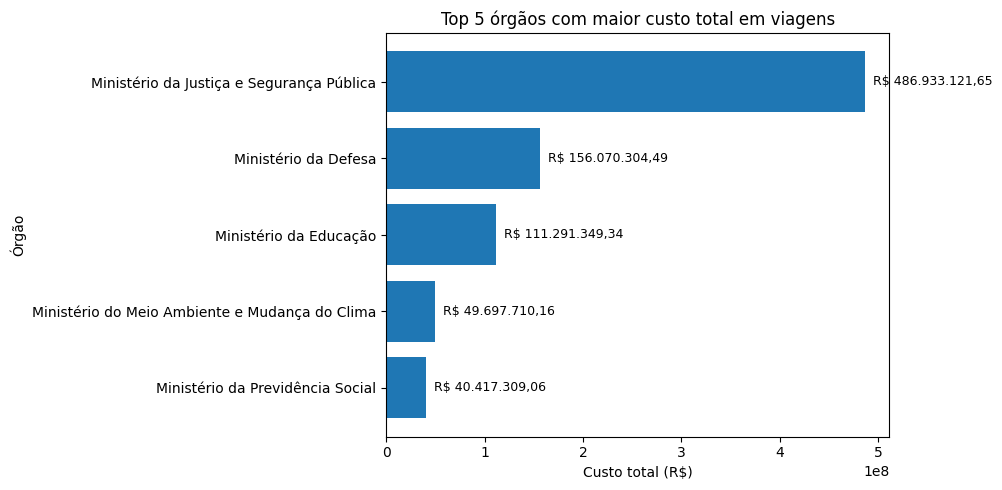

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    q1['orgao'],
    q1['custo_total']
)

ax.invert_yaxis()

ax.set_title('Top 5 órgãos com maior custo total em viagens')
ax.set_xlabel('Custo total (R$)')
ax.set_ylabel('Órgão')

for i, valor in enumerate(q1['custo_total']):
    ax.text(
        valor,
        i,
        '  ' + reais(valor),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Análise dos resultados

A análise identificou os cinco órgãos superiores com maior custo total em viagens
no período avaliado.

O Ministério da Justiça e Segurança Pública apresentou o maior volume de gastos,
seguido pelo Ministério da Defesa e pelo Ministério da Educação. A concentração
dos valores nesses órgãos indica uma maior demanda por deslocamentos relacionados
às suas atividades institucionais.

Essa análise permite identificar quais órgãos possuem maior participação nos gastos
com viagens e pode auxiliar em avaliações futuras relacionadas à quantidade de
viagens realizadas, duração dos deslocamentos e tipos de pagamento utilizados.